In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [8]:
# Remove columns that are 100% empty
df.dropna(axis=1, how='all', inplace=True)

# Convert order dates to a usable format
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'])
print("Data Cleaning Complete!")

Data Cleaning Complete!


In [9]:
# Create a 'is_late' column (1 = Late, 0 = On Time)
df['is_late'] = (df['Days for shipping (real)'] > df['Days for shipment (scheduled)']).astype(int)

# Calculate the percentage of late orders
late_percentage = df['is_late'].mean() * 100
print(f"BMW Supply Chain Health: {late_percentage:.2f}% of orders are late.")

BMW Supply Chain Health: 57.28% of orders are late.


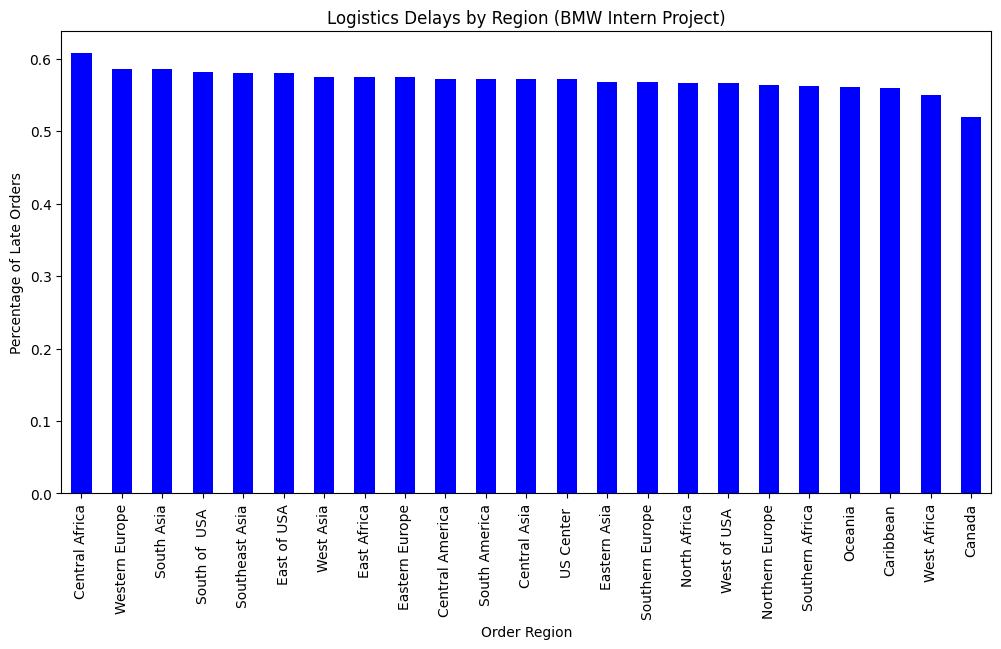

In [10]:
# Find the late rate for each region
region_stats = df.groupby('Order Region')['is_late'].mean().sort_values(ascending=False)

# Create a chart
plt.figure(figsize=(12,6))
region_stats.plot(kind='bar', color='blue')
plt.title('Logistics Delays by Region (BMW Intern Project)')
plt.ylabel('Percentage of Late Orders')
plt.show()